# Download Data

In [1]:
%run ..\assignment3\dataset.py

e:\poetry_cache\virtualenvs\assignment3-HMuFVmZG-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-23 22:15:01.445 | INFO     | config:<module>:11 - PROJ_ROOT path is: D:\MS_DSI\AI\Assignment3\assignment3


2026-04-23 22:15:01.451 | INFO     | __main__:setup_dirs:33 - Directory ready: D:\MS_DSI\AI\Assignment3\assignment3\data\raw
2026-04-23 22:15:01.455 | INFO     | __main__:setup_dirs:33 - Directory ready: D:\MS_DSI\AI\Assignment3\assignment3\data\interim
2026-04-23 22:15:01.455 | INFO     | __main__:setup_dirs:33 - Directory ready: D:\MS_DSI\AI\Assignment3\assignment3\data\processed
2026-04-23 22:15:01.456 | INFO     | __main__:setup_dirs:33 - Directory ready: D:\MS_DSI\AI\Assignment3\assignment3\data\external
2026-04-23 22:15:01.456 | INFO     | __main__:setup_dirs:33 - Directory ready: D:\MS_DSI\AI\Assignment3\assignment3\reports\figures
2026-04-23 22:15:01.457 | INFO     | __main__:download_counsel_chat:39 - Downloading Counsel Chat dataset from Hugging Face...


Repo card metadata block was not found. Setting CardData to empty.


2026-04-23 22:15:05.401 | SUCCESS  | __main__:download_counsel_chat:42 - Counsel Chat saved to D:\MS_DSI\AI\Assignment3\assignment3\data\raw\counsel_chat_raw.csv (2,775 rows)
2026-04-23 22:15:05.403 | INFO     | __main__:download_crisis_data:60 - Downloading crisis detection dataset from Hugging Face...
2026-04-23 22:15:12.193 | SUCCESS  | __main__:download_crisis_data:67 - Crisis data saved to D:\MS_DSI\AI\Assignment3\assignment3\data\raw\crisis_raw.csv (200,000 rows)
2026-04-23 22:15:12.228 | SUCCESS  | __main__:main:74 - All raw datasets downloaded.


# EDA and Basic Cleaning — Mental Health RAG Project

**Goal of this notebook:** understand what's in our raw datasets and produce cleaned versions in `data/interim/`.

**Two datasets:**
1. `counsel_chat_raw.csv` — Q&A pairs from licensed counsellors. Will become our **RAG knowledge base**.
2. `crisis_raw.csv` — Reddit posts labelled suicide/non-suicide. Will become our **classifier training data**.

These need *different* cleaning strategies because they serve different purposes:
- Counsel Chat → quality matters more than quantity (retrieval accuracy)
- Crisis data → volume and label balance matter (classifier generalisation)

## Cell 1 — Imports and setup

In [1]:
import re
import html
import unicodedata
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger

import sys


# 1. Get the path to the parent directory (one level up from where this notebook is)
parent_dir = str(Path.cwd().parent)

# 2. Add it to your system path so Python knows to look there for packages
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# 3. Import using the absolute path (No dots!)
from assignment3.config import RAW_DATA_DIR, INTERIM_DATA_DIR, FIGURES_DIR

# Display settings so we actually see what's in the data
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Raw data dir:     {RAW_DATA_DIR}")
print(f"Interim data dir: {INTERIM_DATA_DIR}")
print(f"Figures dir:      {FIGURES_DIR}")

2026-04-23 22:33:42.849 | INFO     | assignment3.config:<module>:11 - PROJ_ROOT path is: D:\MS_DSI\AI\Assignment3\assignment3


Raw data dir:     D:\MS_DSI\AI\Assignment3\assignment3\data\raw
Interim data dir: D:\MS_DSI\AI\Assignment3\assignment3\data\interim
Figures dir:      D:\MS_DSI\AI\Assignment3\assignment3\reports\figures


---
# Part 1 — Counsel Chat (RAG knowledge base)

## Cell 2 — Load and peek

First thing we do on any dataset: **look at it**. Don't jump to cleaning until you know the shape of the problem.

In [2]:
counsel_raw = pd.read_csv(RAW_DATA_DIR / "counsel_chat_raw.csv")

print(f"Shape: {counsel_raw.shape}")
print(f"\nColumns: {counsel_raw.columns.tolist()}")
print(f"\nDtypes:\n{counsel_raw.dtypes}")
counsel_raw.head(3)

Shape: (2775, 10)

Columns: ['questionID', 'questionTitle', 'questionText', 'questionLink', 'topic', 'therapistInfo', 'therapistURL', 'answerText', 'upvotes', 'views']

Dtypes:
questionID       int64
questionTitle      str
questionText       str
questionLink       str
topic              str
therapistInfo      str
therapistURL       str
answerText         str
upvotes          int64
views            int64
dtype: object


,questionID,questionTitle,questionText,questionLink,topic,therapistInfo,therapistURL,answerText,upvotes,views
0,0,Do I have too many issues for counseling?,"I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac. I have a long history of depression and I’m beginning to have anx...",https://counselchat.com/questions/do-i-have-too-many-issues-for-counseling,depression,Jennifer MolinariHypnotherapist & Licensed Counselor,https://counselchat.com/therapists/jennifer-molinari,"It is very common for people to have multiple issues that they want to (and need to) address in counseling. I have had clients ask that same question and through more exploration, there is often ...",3,1971
1,0,Do I have too many issues for counseling?,"I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac. I have a long history of depression and I’m beginning to have anx...",https://counselchat.com/questions/do-i-have-too-many-issues-for-counseling,depression,"Jason Lynch, MS, LMHC, LCAC, ADSIndividual & Couples Therapy",https://counselchat.com/therapists/jason-lynch-ms-lmhc-lcac-ads,"I've never heard of someone having ""too many issues"" for therapy to be effective. A competent therapist will assist you in identifying the root causes of your problems and treat those first. If th...",2,386
2,0,Do I have too many issues for counseling?,"I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac. I have a long history of depression and I’m beginning to have anx...",https://counselchat.com/questions/do-i-have-too-many-issues-for-counseling,depression,Shakeeta TorresFaith Based Mental Health Counselor,https://counselchat.com/therapists/shakeeta-torres,Absolutely not. I strongly recommending working on one issue/need at a time. In therapy you will set smart goals and objectives that will help you reach your goals. I see you as a survivor and ...,2,3071


## Cell 3 — Random sample (more honest than `.head()`)

`.head()` shows the first rows which are often tidier than the rest. Always sample randomly to see the *real* distribution.

In [3]:
for i, row in counsel_raw.sample(5, random_state=RANDOM_STATE).iterrows():
    print(f"--- Row {i} ---")
    for col in counsel_raw.columns:
        val = row[col]
        if isinstance(val, str) and len(val) > 300:
            val = val[:300] + "..."
        print(f"{col}: {val}")
    print()

--- Row 879 ---
questionID: 250
questionTitle: How should I handle the child I had with my ex-wife?
questionText: My ex-wife married and used me to have a child. She now uses that child as a pawn. I know my child misses me, but I need to move on and not live in the past. How do I do this? Do I see my child as much as possible or very little? Is it more confusing for the child?
questionLink: https://counselchat.com/questions/how-should-i-handle-the-child-i-had-with-my-ex-wife
topic: parenting
therapistInfo: Sherry Katz, LCSWCouples and Family Therapist, LCSW
therapistURL: https://counselchat.com/therapists/sherry-katz-lcsw
answerText: What are the ways your ex-wife uses your child as a pawn?This answer determines the best ways to handle particular situations.Basically, distinguish that your father relationship to your child lasts has great meaning for your child and as the adult, the responsibility for managing this relationship ...
upvotes: 0
views: 77

--- Row 1989 ---
questionID: 699

## Cell 4 — Missing values and duplicates

Every dataset has some of both. Find out how much before deciding what to drop.

In [4]:
print("Missing values per column:")
print(counsel_raw.isna().sum())
print(f"\nTotal rows: {len(counsel_raw):,}")
print(f"Exact duplicate rows: {counsel_raw.duplicated().sum():,}")

# More useful: duplicates on the content columns only
# (typically questionText + answerText on this dataset; adjust if names differ)
content_cols = [c for c in counsel_raw.columns if c.lower() in
                {"questiontext", "answertext", "questiontitle", "question", "answer"}]
print(f"\nContent columns detected: {content_cols}")
if content_cols:
    print(f"Duplicates on content columns: {counsel_raw.duplicated(subset=content_cols).sum():,}")

Missing values per column:
questionID         0
questionTitle      0
questionText     139
questionLink       0
topic              0
therapistInfo      0
therapistURL       0
answerText        26
upvotes            0
views              0
dtype: int64

Total rows: 2,775
Exact duplicate rows: 0

Content columns detected: ['questionTitle', 'questionText', 'answerText']
Duplicates on content columns: 2


## Cell 5 — Topic distribution

Counsel Chat has a `topic` column. Knowing the distribution matters for the project:
- An imbalanced knowledge base means some topics will have poor retrieval
- For the ethics slide, we can say "our KB is biased toward topics X, Y, Z"

Unique topics: 31
topic
depression                  465
anxiety                     358
counseling-fundamentals     270
intimacy                    248
relationships               202
parenting                   191
family-conflict             144
trauma                      102
self-esteem                 100
relationship-dissolution     98
behavioral-change            69
lgbtq                        65
marriage                     52
anger-management             48
spirituality                 47
substance-abuse              45
professional-ethics          41
grief-and-loss               37
workplace-relationships      36
social-relationships         25
Name: count, dtype: int64


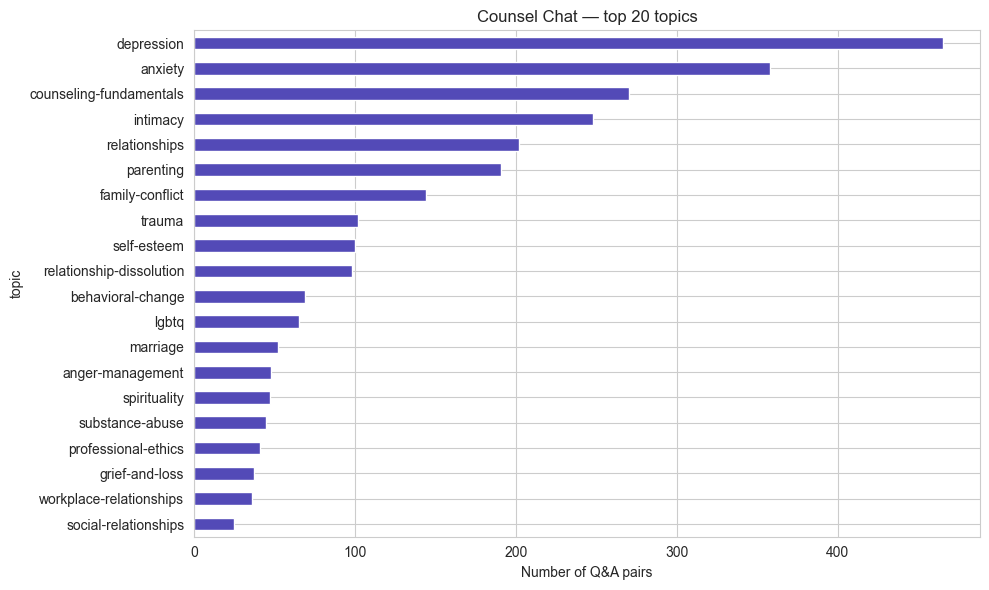

In [5]:
if "topic" in counsel_raw.columns:
    topic_counts = counsel_raw["topic"].value_counts()
    print(f"Unique topics: {len(topic_counts)}")
    print(topic_counts.head(20))

    fig, ax = plt.subplots(figsize=(10, 6))
    topic_counts.head(20).plot(kind="barh", ax=ax, color="#534AB7")
    ax.invert_yaxis()
    ax.set_xlabel("Number of Q&A pairs")
    ax.set_title("Counsel Chat — top 20 topics")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "counsel_topic_distribution.png", dpi=120)
    plt.show()
else:
    print("No 'topic' column — skipping.")

## Cell 6 — Text length distributions

Chunking strategy depends on this. If most answers are 500 tokens, a 300-token chunk size will split them weirdly.

Question col: questionText | Answer col: answerText

Question length stats (words):
count    2775.0
mean       49.2
std        43.2
min         0.0
25%        24.0
50%        41.0
75%        63.0
max       526.0
Name: q_words, dtype: float64

Answer length stats (words):
count    2775.0
mean      166.4
std       119.0
min         0.0
25%        86.0
50%       134.0
75%       212.0
max       939.0
Name: a_words, dtype: float64


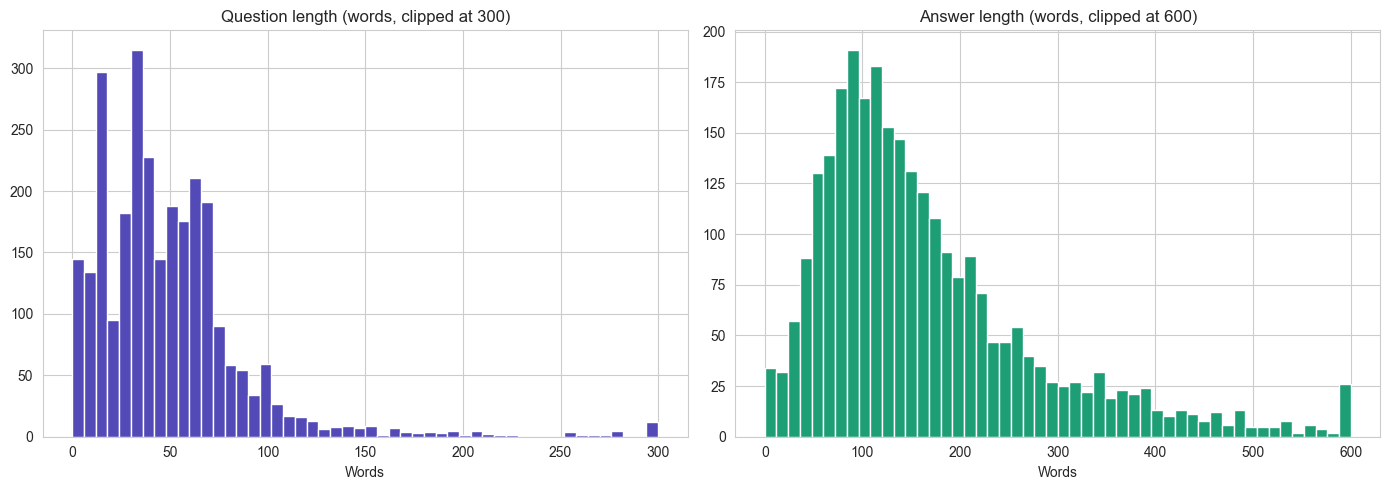

In [6]:
# Work out which columns hold the question and answer text
q_col = next((c for c in ["questionText", "question", "questionTitle"] if c in counsel_raw.columns), None)
a_col = next((c for c in ["answerText", "answer"] if c in counsel_raw.columns), None)
print(f"Question col: {q_col} | Answer col: {a_col}")

def char_len(series):
    return series.fillna("").astype(str).str.len()

def word_len(series):
    return series.fillna("").astype(str).str.split().str.len()

if q_col and a_col:
    counsel_raw["q_chars"] = char_len(counsel_raw[q_col])
    counsel_raw["a_chars"] = char_len(counsel_raw[a_col])
    counsel_raw["q_words"] = word_len(counsel_raw[q_col])
    counsel_raw["a_words"] = word_len(counsel_raw[a_col])

    print("\nQuestion length stats (words):")
    print(counsel_raw["q_words"].describe().round(1))
    print("\nAnswer length stats (words):")
    print(counsel_raw["a_words"].describe().round(1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(counsel_raw["q_words"].clip(upper=300), bins=50, color="#534AB7", edgecolor="white")
    axes[0].set_title("Question length (words, clipped at 300)")
    axes[0].set_xlabel("Words")
    axes[1].hist(counsel_raw["a_words"].clip(upper=600), bins=50, color="#1D9E75", edgecolor="white")
    axes[1].set_title("Answer length (words, clipped at 600)")
    axes[1].set_xlabel("Words")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "counsel_length_distribution.png", dpi=120)
    plt.show()

## Cell 7 — Look at the extremes

The very shortest and very longest rows are where garbage lives. If we plan to filter by length, we need to see what gets dropped.

In [7]:
if q_col and a_col:
    print("=== 5 SHORTEST answers ===")
    for _, row in counsel_raw.nsmallest(5, "a_words").iterrows():
        print(f"[{row['a_words']} words] Q: {str(row[q_col])[:80]}...")
        print(f"              A: {row[a_col]!r}\n")

    print("=== 3 LONGEST answers ===")
    for _, row in counsel_raw.nlargest(3, "a_words").iterrows():
        print(f"[{row['a_words']} words] Q: {str(row[q_col])[:80]}...")
        print(f"              A (first 300 chars): {str(row[a_col])[:300]}...\n")

=== 5 SHORTEST answers ===
[0 words] Q: Every winter I find myself getting sad because of the weather. How can I fight t...
              A: nan

[0 words] Q: I can't even smile or fake one. I can't feel happiness about anything and I can'...
              A: nan

[0 words] Q: After my aunt passed away, I feel like I'm a different person. I don't talk to m...
              A: nan

[0 words] Q: When I'm in large crowds I get angry and I just can't deal with people. I don't ...
              A: nan

[0 words] Q: I just took a job that requires me to travel far away from home. My family and I...
              A: nan

=== 3 LONGEST answers ===
[939 words] Q: How do I decide if I should end my relationship with my boyfriend?...
              A (first 300 chars): Previous counselors have discussed very good points about your situation so I would like just to confirm what seems essential to me on this topic. When you ask yourself this question, it shows you are not happy or have doubts about 

## Cell 8 — Define the text cleaning function

Pipeline (in order — order matters):
1. HTML unescape (`&amp;` → `&`)
2. Unicode normalise (NFKC — canonical form)
3. Strip URLs
4. Strip Reddit-style artefacts (`/u/`, `/r/`, `[deleted]`, etc.)
5. Strip simple markdown (`**`, `*`, `>`)
6. Strip all non-ASCII (as chosen)
7. Collapse whitespace
8. Strip leading/trailing whitespace

In [8]:
URL_RE          = re.compile(r"http\S+|www\.\S+")
REDDIT_USER_RE  = re.compile(r"/?[ur]/[A-Za-z0-9_\-]+")
REDDIT_META_RE  = re.compile(r"\[(deleted|removed)\]", re.IGNORECASE)
MARKDOWN_RE     = re.compile(r"(\*\*|__|\*|_|^>+ ?)", re.MULTILINE)
NON_ASCII_RE    = re.compile(r"[^\x00-\x7F]+")
WHITESPACE_RE   = re.compile(r"\s+")


def clean_text(text: str) -> str:
    """Normalise free-text strings for downstream NLP tasks."""
    if not isinstance(text, str) or not text:
        return ""

    # 1. HTML entities
    text = html.unescape(text)

    # 2. Unicode normalise (canonical form)
    text = unicodedata.normalize("NFKC", text)

    # 3. URLs
    text = URL_RE.sub(" ", text)

    # 4. Reddit artefacts
    text = REDDIT_USER_RE.sub(" ", text)
    text = REDDIT_META_RE.sub(" ", text)

    # 5. Markdown
    text = MARKDOWN_RE.sub(" ", text)

    # 6. Strip non-ASCII (loses emoji, accents)
    text = NON_ASCII_RE.sub(" ", text)

    # 7. Collapse whitespace
    text = WHITESPACE_RE.sub(" ", text)

    # 8. Trim
    return text.strip()


# Quick sanity test
test_cases = [
    "   Hi   there!!  ",
    "Check http://example.com/foo?bar=1 for more info.",
    "This &amp; that &#x2014; see /u/someuser on /r/depression",
    "I feel naïve and café-ish 😢💔",
    "[deleted] by moderator",
    "**Bold** and *italic* and > quoted text",
    None,
    "",
]
for t in test_cases:
    print(f"{t!r:60s} -> {clean_text(t)!r}")

'   Hi   there!!  '                                          -> 'Hi there!!'
'Check http://example.com/foo?bar=1 for more info.'          -> 'Check for more info.'
'This &amp; that &#x2014; see /u/someuser on /r/depression'  -> 'This & that see on'
'I feel naïve and café-ish 😢💔'                               -> 'I feel na ve and caf -ish'
'[deleted] by moderator'                                     -> 'by moderator'
'**Bold** and *italic* and > quoted text'                    -> 'Bold and italic and > quoted text'
None                                                         -> ''
''                                                           -> ''


## Cell 9 — Apply cleaning to Counsel Chat

Strategy:
1. Drop rows with missing question OR answer (can't use them for RAG)
2. Clean both columns
3. Drop rows where cleaning made the text empty or near-empty
4. Deduplicate on cleaned content
5. Filter by length (remove very short answers — usually junk)

In [9]:
counsel = counsel_raw.copy()
n0 = len(counsel)

# 1. Drop rows missing core content
counsel = counsel.dropna(subset=[q_col, a_col])
n1 = len(counsel)

# 2. Clean text
counsel["question_clean"] = counsel[q_col].apply(clean_text)
counsel["answer_clean"]   = counsel[a_col].apply(clean_text)

# 3. Drop rows where cleaning emptied the content
counsel = counsel[(counsel["question_clean"].str.len() > 10) &
                  (counsel["answer_clean"].str.len() > 20)]
n2 = len(counsel)

# 4. Dedupe on cleaned content
counsel = counsel.drop_duplicates(subset=["question_clean", "answer_clean"])
n3 = len(counsel)

# 5. Length filter — keep reasonable answers
counsel["a_words_clean"] = counsel["answer_clean"].str.split().str.len()
counsel = counsel[(counsel["a_words_clean"] >= 15) & (counsel["a_words_clean"] <= 1000)]
n4 = len(counsel)

print(f"Rows after each step:")
print(f"  start              : {n0:,}")
print(f"  drop NA content    : {n1:,}  (-{n0-n1:,})")
print(f"  non-empty clean    : {n2:,}  (-{n1-n2:,})")
print(f"  drop duplicates    : {n3:,}  (-{n2-n3:,})")
print(f"  length filter      : {n4:,}  (-{n3-n4:,})")
print(f"\nFinal retention: {n4/n0*100:.1f}%")

Rows after each step:
  start              : 2,775
  drop NA content    : 2,612  (-163)
  non-empty clean    : 2,611  (-1)
  drop duplicates    : 2,611  (-0)
  length filter      : 2,599  (-12)

Final retention: 93.7%


## Cell 10 — Before/after comparison

Always verify cleaning did what you expected on real examples — not just the test cases.

In [10]:
for _, row in counsel.sample(3, random_state=RANDOM_STATE).iterrows():
    print("=== BEFORE ===")
    print(f"Q: {str(row[q_col])[:250]}")
    print(f"A: {str(row[a_col])[:250]}")
    print("\n=== AFTER ===")
    print(f"Q: {row['question_clean'][:250]}")
    print(f"A: {row['answer_clean'][:250]}")
    print("\n" + "-" * 80 + "\n")

=== BEFORE ===
Q: We've been dating for two months now. I have a heavy past that gets him angry. Does he have a right to penalize me for things I did before I met him?
A: Not in my book. You're only two months in? At this early stage, this is a bit of a warning sign. If he can't accept or feel comfortable with who you are and decisions you've made, there's already a level of discomfort here that shouldn't be ignored. 

=== AFTER ===
Q: We've been dating for two months now. I have a heavy past that gets him angry. Does he have a right to penalize me for things I did before I met him?
A: Not in my book. You're only two months in? At this early stage, this is a bit of a warning sign. If he can't accept or feel comfortable with who you are and decisions you've made, there's already a level of discomfort here that shouldn't be ignored. 

--------------------------------------------------------------------------------

=== BEFORE ===
Q: I struggle with depression as well as pretty intense mo

## Cell 11 — Save cleaned Counsel Chat to interim

In [11]:
keep_cols = ["question_clean", "answer_clean", "a_words_clean"]
if "topic" in counsel.columns:
    keep_cols.insert(0, "topic")

out_path = INTERIM_DATA_DIR / "counsel_chat_clean.csv"
counsel[keep_cols].to_csv(out_path, index=False)
logger.success(f"Saved {len(counsel):,} cleaned rows to {out_path}")

2026-04-23 22:33:49.244 | SUCCESS  | __main__:<module>:7 - Saved 2,599 cleaned rows to D:\MS_DSI\AI\Assignment3\assignment3\data\interim\counsel_chat_clean.csv


---
# Part 2 — Crisis Detection Dataset

## Cell 12 — Load and peek

In [12]:
crisis_raw = pd.read_csv(RAW_DATA_DIR / "crisis_raw.csv")

print(f"Shape: {crisis_raw.shape}")
print(f"\nColumns: {crisis_raw.columns.tolist()}")
print(f"\nDtypes:\n{crisis_raw.dtypes}")
crisis_raw.head(3)

Shape: (200000, 2)

Columns: ['text', 'label']

Dtypes:
text       str
label    int64
dtype: object


,text,label
0,bruh why can’t i have a normal dream every fucking night i’m always in this weird ass situation in a place that doesn’t exist and most of the time i end up dying like can i just have a normal drea...,0
1,my school doesn’t block facebook on the wifi but it does block indeed so the teachers can go on there all they want but so help me if i wanna look for a job in my down time,0
2,day 430 of recommending songs i like to r/teenagers://youtu.be/biyl9bcp6w4\n\nhow has your day been so far?,0


## Cell 13 — Label balance

Imbalance drives the training strategy. If one class is 90% of the data, accuracy is meaningless — you need F1 or class-weighted loss.

Text col: text | Label col: label

Label counts:
label
0    100000
1    100000
Name: count, dtype: int64

Label proportions:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


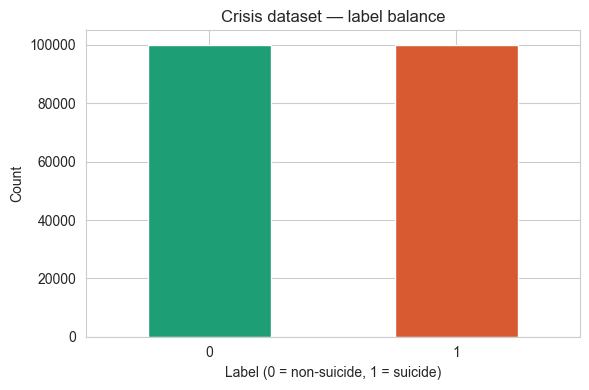

In [13]:
label_col = "label" if "label" in crisis_raw.columns else "class"
text_col = "text" if "text" in crisis_raw.columns else crisis_raw.columns[0]
print(f"Text col: {text_col} | Label col: {label_col}")

print("\nLabel counts:")
print(crisis_raw[label_col].value_counts())
print("\nLabel proportions:")
print(crisis_raw[label_col].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
crisis_raw[label_col].value_counts().plot(kind="bar", ax=ax, color=["#1D9E75", "#D85A30"])
ax.set_title("Crisis dataset — label balance")
ax.set_xlabel("Label (0 = non-suicide, 1 = suicide)")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "crisis_label_balance.png", dpi=120)
plt.show()

## Cell 14 — Random samples per class

Read a few from each class so you understand what the labels actually mean. Crisis datasets are noisy — some "suicide" posts are venting, some "non-suicide" posts are masked cries for help.

In [14]:
for lbl in sorted(crisis_raw[label_col].dropna().unique()):
    print(f"\n=== LABEL = {lbl} (sample of 3) ===")
    sample = crisis_raw[crisis_raw[label_col] == lbl].sample(3, random_state=RANDOM_STATE)
    for _, row in sample.iterrows():
        txt = str(row[text_col])
        print(f"• {txt[:300]}{'...' if len(txt) > 300 else ''}\n")


=== LABEL = 0 (sample of 3) ===
• i find it kinda annoying how people try to sell religion in the street i was minding my own business and this guy walked up to me and my dad, tried to make small talk, and then started saying religious stuff and pulled out his "religious book of answers" and kept trynna make us ask questions about r...

• people don't take eating disorders seriously except for anorexia anorexia is a big deal but there are a lot of other harmful eating disorders as well that are hardly taken into consideration, like when you think of eating disorders you normally only think of anorexia when there are so many that aren...

• my baby brothers so pretty mf rlly took my parents best genes smh 

hes gonna be so attractive when he grows up tho awe he looks rlly fem tho


=== LABEL = 1 (sample of 3) ===
• how to date again after traumathree years ago i had practically all the bones in my face broken when i was assaulted in a bar. two years ago i nearly died of opoid and morph

## Cell 15 — Missing values and duplicates

In [15]:
print("Missing values:")
print(crisis_raw.isna().sum())
print(f"\nExact duplicate rows: {crisis_raw.duplicated().sum():,}")
print(f"Duplicate texts:      {crisis_raw.duplicated(subset=[text_col]).sum():,}")

Missing values:
text     0
label    0
dtype: int64

Exact duplicate rows: 10
Duplicate texts:      10


## Cell 16 — Text length distribution per class

If one class is systematically longer, the model might learn length as a shortcut instead of real signal.

Word count by label:
          count   mean    std  min   25%    50%    75%     max
label                                                         
0      100000.0   60.0  131.1  1.0  18.0   31.0   60.0  8220.0
1      100000.0  224.8  271.1  1.0  69.0  144.0  279.0  7753.0


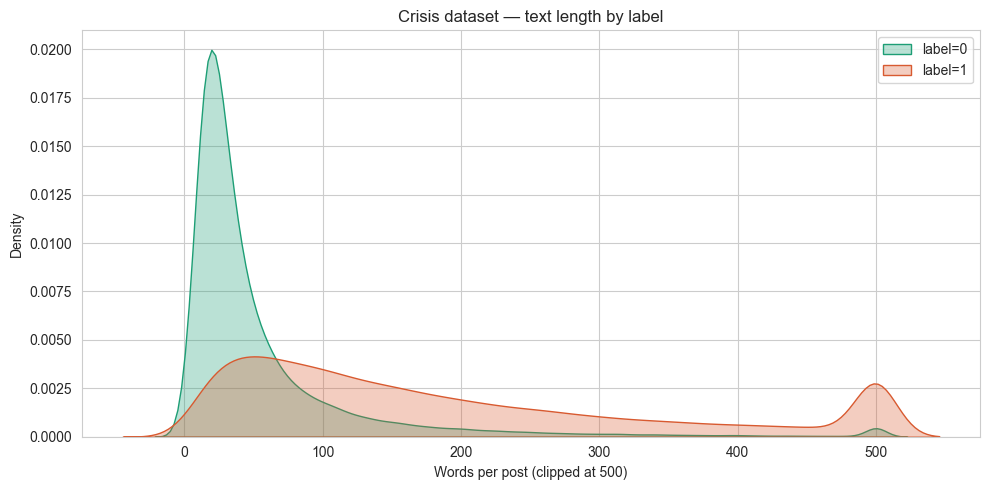

In [16]:
crisis_raw["n_words"] = crisis_raw[text_col].fillna("").astype(str).str.split().str.len()

print("Word count by label:")
print(crisis_raw.groupby(label_col)["n_words"].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 5))
for lbl, colour in zip(sorted(crisis_raw[label_col].dropna().unique()), ["#1D9E75", "#D85A30"]):
    sns.kdeplot(
        crisis_raw.loc[crisis_raw[label_col] == lbl, "n_words"].clip(upper=500),
        label=f"label={lbl}", ax=ax, color=colour, fill=True, alpha=0.3,
    )
ax.set_xlabel("Words per post (clipped at 500)")
ax.set_title("Crisis dataset — text length by label")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "crisis_length_by_label.png", dpi=120)
plt.show()

## Cell 17 — Apply cleaning to crisis data

In [17]:
crisis = crisis_raw.copy()
m0 = len(crisis)

# 1. Drop NA
crisis = crisis.dropna(subset=[text_col, label_col])
m1 = len(crisis)

# 2. Clean text
crisis["text_clean"] = crisis[text_col].apply(clean_text)

# 3. Drop empty-after-cleaning
crisis = crisis[crisis["text_clean"].str.len() > 10]
m2 = len(crisis)

# 4. Dedupe
crisis = crisis.drop_duplicates(subset=["text_clean"])
m3 = len(crisis)

# 5. Length filter — DistilBERT truncates at 512 tokens (~400 words), so drop
#    extreme outliers but keep a wide range for the model to learn from
crisis["n_words_clean"] = crisis["text_clean"].str.split().str.len()
crisis = crisis[(crisis["n_words_clean"] >= 3) & (crisis["n_words_clean"] <= 600)]
m4 = len(crisis)

print(f"Rows after each step:")
print(f"  start           : {m0:,}")
print(f"  drop NA         : {m1:,}  (-{m0-m1:,})")
print(f"  non-empty clean : {m2:,}  (-{m1-m2:,})")
print(f"  drop duplicates : {m3:,}  (-{m2-m3:,})")
print(f"  length filter   : {m4:,}  (-{m3-m4:,})")
print(f"\nFinal retention: {m4/m0*100:.1f}%")
print(f"\nClass balance after cleaning:")
print(crisis[label_col].value_counts(normalize=True).round(3))

Rows after each step:
  start           : 200,000
  drop NA         : 200,000  (-0)
  non-empty clean : 199,876  (-124)
  drop duplicates : 199,748  (-128)
  length filter   : 192,294  (-7,454)

Final retention: 96.1%

Class balance after cleaning:
label
0    0.516
1    0.484
Name: proportion, dtype: float64


## Cell 18 — Before/after sanity check

In [18]:
for _, row in crisis.sample(3, random_state=RANDOM_STATE).iterrows():
    print(f"label = {row[label_col]}")
    print(f"BEFORE: {str(row[text_col])[:300]}")
    print(f"AFTER : {row['text_clean'][:300]}")
    print("-" * 80)

label = 0
BEFORE: i wanna get face tats tbh i wanna just send a message of “fuck what people think” and just be me without having to do what people expect
AFTER : i wanna get face tats tbh i wanna just send a message of fuck what people think and just be me without having to do what people expect
--------------------------------------------------------------------------------
label = 0
BEFORE: now repeat after me, fellow soldiers my mental health does matters
my mental heatlh does matters
my mental health does matters
my mental health does matters
my mental health does matters.
AFTER : now repeat after me, fellow soldiers my mental health does matters my mental heatlh does matters my mental health does matters my mental health does matters my mental health does matters.
--------------------------------------------------------------------------------
label = 0
BEFORE: not that anyone cares heres one of my favourite songs to sing along to and its lyrics. i know all the lyrics of by heart

## Cell 19 — Save cleaned crisis data to interim

In [19]:
out_path = INTERIM_DATA_DIR / "crisis_clean.csv"
crisis[["text_clean", label_col, "n_words_clean"]].to_csv(out_path, index=False)
logger.success(f"Saved {len(crisis):,} cleaned rows to {out_path}")

2026-04-23 22:34:37.240 | SUCCESS  | __main__:<module>:3 - Saved 192,294 cleaned rows to D:\MS_DSI\AI\Assignment3\assignment3\data\interim\crisis_clean.csv


---
## Summary

Outputs written to `data/interim/`:
- `counsel_chat_clean.csv` — ready for **chunking** and FAISS indexing (Member 2's job)
- `crisis_clean.csv` — ready for **train/val/test split** and DistilBERT fine-tuning (Member 3's job)

Figures in `reports/figures/`:
- `counsel_topic_distribution.png`
- `counsel_length_distribution.png`
- `crisis_label_balance.png`
- `crisis_length_by_label.png`

**Next notebooks:**
- `02_counsel_chunking.ipynb` — split cleaned Q&A into retrieval-sized chunks
- `03_crisis_train_val_test_split.ipynb` — stratified splits for the classifier

**For the slide deck (ethics slide):** note exactly how many rows were dropped at each stage and why. Transparency about preprocessing decisions earns marks on the ethics and data provenance criterion.